# BCI Competition IV - Dataset 2a: Exploratory Data Analysis (Kaggle)

4-class cued motor imagery EEG (left hand, right hand, feet, tongue).
22 EEG channels + 3 EOG channels, 250 Hz, 9 subjects, 2 sessions each (`A0XT.gdf` train / `A0XE.gdf` test).

In [19]:
# Kaggle notebooks don't have mne preinstalled by default — install it once per session
!pip install -q mne

In [20]:
import glob
import mne
import numpy as np
import matplotlib.pyplot as plt

# --- Auto-discover input files ---
gdf_files = sorted(glob.glob("/kaggle/input/**/*.gdf", recursive=True))
mat_files = sorted(glob.glob("/kaggle/input/**/*.mat", recursive=True))

print(f"Found {len(gdf_files)} .gdf file(s):")
for f in gdf_files:
    print(" ", f)
if not gdf_files and mat_files:
    print(f"\nNo .gdf files found, but {len(mat_files)} .mat file(s) exist instead "
          f"(your dataset is likely the .mat-format version — the loader below needs "
          f"scipy.io.loadmat rather than mne.io.read_raw_gdf; let me know and I'll adapt it):")
    for f in mat_files:
        print(" ", f)

# --- Config ---
# IMPORTANT: 2a files come in pairs per subject — "T" (training, labels included)
# and "E" (evaluation, class cues are masked as code 783/"unknown" since labels
# were withheld for the competition). This notebook's ERD/ERS and class-balance
# cells need real class labels, so we default to a "T" file if one is available.
train_files = [f for f in gdf_files if "T.gdf" in f or "train" in f.lower()]
eval_files = [f for f in gdf_files if "E.gdf" in f or "eval" in f.lower()]

if train_files:
    FILE_PATH = train_files[0]
elif gdf_files:
    FILE_PATH = gdf_files[0]
    print("\nWARNING: no filename matched a 'T' (training) pattern — defaulting to the "
          "first .gdf file found. If this turns out to be an evaluation ('E') file, "
          "class cues will be masked as 'unknown' and epoching will fail below. "
          "Set FILE_PATH manually to a *T.gdf file instead.")
else:
    FILE_PATH = "CHANGE_ME.gdf"

print(f"\nUsing FILE_PATH = {FILE_PATH}")

# 2a cue event codes (per dataset description desc_2a.pdf):
# 769 = left hand, 770 = right hand, 771 = foot, 772 = tongue, 783 = unknown (eval set)
CUE_CODES = {"769": "left_hand", "770": "right_hand", "771": "foot", "772": "tongue", "783": "unknown"}

def find_channel(target, ch_names):
    """2a GDF channels are often prefixed, e.g. 'EEG-C3' rather than plain 'C3'.
    Match exact name first, then suffix after a separator, then substring, case-insensitive."""
    t = target.lower()
    for c in ch_names:
        if c.lower() == t:
            return c
    for c in ch_names:
        cl = c.lower()
        if cl.endswith("-" + t) or cl.endswith("_" + t) or cl.endswith(":" + t):
            return c
    for c in ch_names:
        if t in c.lower():
            return c
    return None

Found 18 .gdf file(s):
  /kaggle/input/datasets/sababahoquesaba/bciciv-2a/A01E.gdf
  /kaggle/input/datasets/sababahoquesaba/bciciv-2a/A01T.gdf
  /kaggle/input/datasets/sababahoquesaba/bciciv-2a/A02E.gdf
  /kaggle/input/datasets/sababahoquesaba/bciciv-2a/A02T.gdf
  /kaggle/input/datasets/sababahoquesaba/bciciv-2a/A03E.gdf
  /kaggle/input/datasets/sababahoquesaba/bciciv-2a/A03T.gdf
  /kaggle/input/datasets/sababahoquesaba/bciciv-2a/A04E.gdf
  /kaggle/input/datasets/sababahoquesaba/bciciv-2a/A04T.gdf
  /kaggle/input/datasets/sababahoquesaba/bciciv-2a/A05E.gdf
  /kaggle/input/datasets/sababahoquesaba/bciciv-2a/A05T.gdf
  /kaggle/input/datasets/sababahoquesaba/bciciv-2a/A06E.gdf
  /kaggle/input/datasets/sababahoquesaba/bciciv-2a/A06T.gdf
  /kaggle/input/datasets/sababahoquesaba/bciciv-2a/A07E.gdf
  /kaggle/input/datasets/sababahoquesaba/bciciv-2a/A07T.gdf
  /kaggle/input/datasets/sababahoquesaba/bciciv-2a/A08E.gdf
  /kaggle/input/datasets/sababahoquesaba/bciciv-2a/A08T.gdf
  /kaggle/input/d

## 1. Load raw data

In [21]:
assert FILE_PATH != "CHANGE_ME.gdf", "Set FILE_PATH to one of the discovered .gdf files above."
raw = mne.io.read_raw_gdf(FILE_PATH, preload=True, verbose="ERROR")
events, event_id = mne.events_from_annotations(raw, verbose="ERROR")

print(f"Channels ({len(raw.ch_names)}): {raw.ch_names}")
print(f"Sampling rate: {raw.info['sfreq']} Hz")
print(f"Duration: {raw.times[-1]:.1f} s")
print(f"Total annotated events: {len(events)}")
print(f"Event id mapping (raw annotation codes): {event_id}")

Channels (25): ['EEG-Fz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3', 'EEG-4', 'EEG-5', 'EEG-C3', 'EEG-6', 'EEG-Cz', 'EEG-7', 'EEG-C4', 'EEG-8', 'EEG-9', 'EEG-10', 'EEG-11', 'EEG-12', 'EEG-13', 'EEG-14', 'EEG-Pz', 'EEG-15', 'EEG-16', 'EOG-left', 'EOG-central', 'EOG-right']
Sampling rate: 250.0 Hz
Duration: 2690.1 s
Total annotated events: 603
Event id mapping (raw annotation codes): {np.str_('1023'): 1, np.str_('1072'): 2, np.str_('276'): 3, np.str_('277'): 4, np.str_('32766'): 5, np.str_('768'): 6, np.str_('769'): 7, np.str_('770'): 8, np.str_('771'): 9, np.str_('772'): 10}


## 2. Structural summary - event code counts
Cross-reference the raw annotation codes above against `CUE_CODES` to identify which map to actual motor-imagery cues vs. other markers (e.g. start-of-trial, rejected-trial, eye-movement artifact markers also present in 2a's GDF files).

In [22]:
codes, counts = np.unique(events[:, 2], return_counts=True)
inv_map = {v: k for k, v in event_id.items()}
for c, n in zip(codes, counts):
    raw_code = inv_map.get(c, str(c))
    label = CUE_CODES.get(raw_code, "other/non-cue marker")
    print(f"code {c} (raw annotation {raw_code!r}): {n} occurrences -> {label}")

code 1 (raw annotation np.str_('1023')): 15 occurrences -> other/non-cue marker
code 2 (raw annotation np.str_('1072')): 1 occurrences -> other/non-cue marker
code 3 (raw annotation np.str_('276')): 1 occurrences -> other/non-cue marker
code 4 (raw annotation np.str_('277')): 1 occurrences -> other/non-cue marker
code 5 (raw annotation np.str_('32766')): 9 occurrences -> other/non-cue marker
code 6 (raw annotation np.str_('768')): 288 occurrences -> other/non-cue marker
code 7 (raw annotation np.str_('769')): 72 occurrences -> left_hand
code 8 (raw annotation np.str_('770')): 72 occurrences -> right_hand
code 9 (raw annotation np.str_('771')): 72 occurrences -> foot
code 10 (raw annotation np.str_('772')): 72 occurrences -> tongue


## 3. Class balance (motor-imagery cues only)

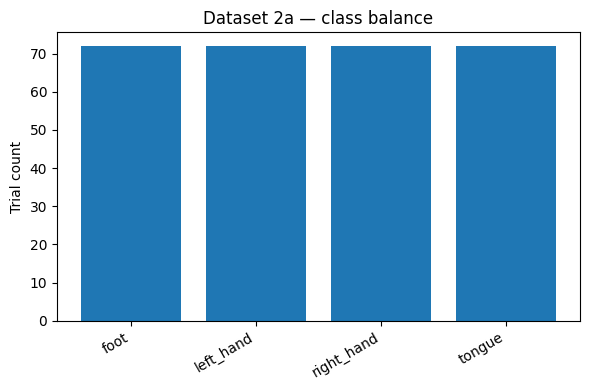

{np.str_('foot'): np.int64(72), np.str_('left_hand'): np.int64(72), np.str_('right_hand'): np.int64(72), np.str_('tongue'): np.int64(72)}


In [23]:
cue_ids = {k: v for k, v in event_id.items() if k in CUE_CODES and CUE_CODES[k] != "unknown"}

if not cue_ids:
    raise ValueError(
        f"No labeled motor-imagery cues (769-772) found in this file's annotations "
        f"(only found codes: {list(event_id.keys())}). This almost always means "
        f"FILE_PATH points to an evaluation ('E') file, where cues are masked as "
        f"'unknown' (783). Re-run from the setup cell with FILE_PATH set to the "
        f"matching 'T' (training) file for this subject instead."
    )

cue_events = events[np.isin(events[:, 2], list(cue_ids.values()))]

labels = [CUE_CODES[inv_map[c]] for c in cue_events[:, 2]]
uniq, cnt = np.unique(labels, return_counts=True)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(uniq, cnt)
ax.set_ylabel("Trial count")
ax.set_title("Dataset 2a — class balance")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print(dict(zip(uniq, cnt)))

## 4. Signal quality - amplitude range and EOG contamination
Checks flat/saturated channels and correlates the 3 EOG channels against frontal EEG channels (Fz-adjacent) to flag likely eye-movement contamination.

In [24]:
data = raw.get_data()
ch_names = raw.ch_names

print("Per-channel amplitude range (min, max) in Volts:")
for name, sig in zip(ch_names, data):
    print(f"  {name:>6}: [{sig.min():.2e}, {sig.max():.2e}]  std={sig.std():.2e}")

eog_chs = [c for c in ch_names if "EOG" in c.upper()]
frontal_chs = [find_channel(t, ch_names) for t in ("Fz", "FC1", "FC2")]
frontal_chs = [c for c in frontal_chs if c is not None]
print(f"\nEOG channels found: {eog_chs}")
print(f"Frontal EEG channels found: {frontal_chs}")

if eog_chs and frontal_chs:
    eog_sig = data[ch_names.index(eog_chs[0])]
    for fc in frontal_chs:
        corr = np.corrcoef(eog_sig, data[ch_names.index(fc)])[0, 1]
        print(f"corr(EOG, {fc}) = {corr:.3f}")

Per-channel amplitude range (min, max) in Volts:
  EEG-Fz: [-1.60e-03, 1.00e-04]  std=5.72e-05
   EEG-0: [-1.60e-03, 1.00e-04]  std=5.65e-05
   EEG-1: [-1.60e-03, 1.00e-04]  std=5.67e-05
   EEG-2: [-1.60e-03, 1.00e-04]  std=5.68e-05
   EEG-3: [-1.60e-03, 1.00e-04]  std=5.67e-05
   EEG-4: [-1.60e-03, 1.00e-04]  std=5.67e-05
   EEG-5: [-1.60e-03, 1.00e-04]  std=5.60e-05
  EEG-C3: [-1.60e-03, 1.00e-04]  std=5.63e-05
   EEG-6: [-1.60e-03, 1.00e-04]  std=5.64e-05
  EEG-Cz: [-1.60e-03, 1.00e-04]  std=5.66e-05
   EEG-7: [-1.60e-03, 1.00e-04]  std=5.65e-05
  EEG-C4: [-1.60e-03, 1.00e-04]  std=5.64e-05
   EEG-8: [-1.60e-03, 1.00e-04]  std=5.63e-05
   EEG-9: [-1.60e-03, 1.00e-04]  std=5.62e-05
  EEG-10: [-1.60e-03, 1.00e-04]  std=5.63e-05
  EEG-11: [-1.60e-03, 1.00e-04]  std=5.64e-05
  EEG-12: [-1.60e-03, 1.00e-04]  std=5.64e-05
  EEG-13: [-1.60e-03, 1.00e-04]  std=5.63e-05
  EEG-14: [-1.60e-03, 1.00e-04]  std=5.62e-05
  EEG-Pz: [-1.60e-03, 1.00e-04]  std=5.63e-05
  EEG-15: [-1.60e-03, 1.00e-04]

## 5. Spectral EDA - power spectral density

Plotting power spectral density (dB=True).


/tmp/ipykernel_58/319800023.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.compute_psd(fmax=40.0, picks="eeg", verbose="ERROR").plot(show=True)


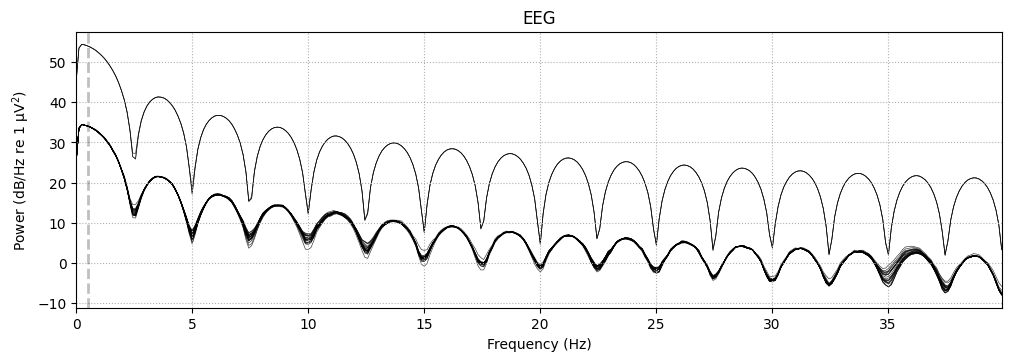

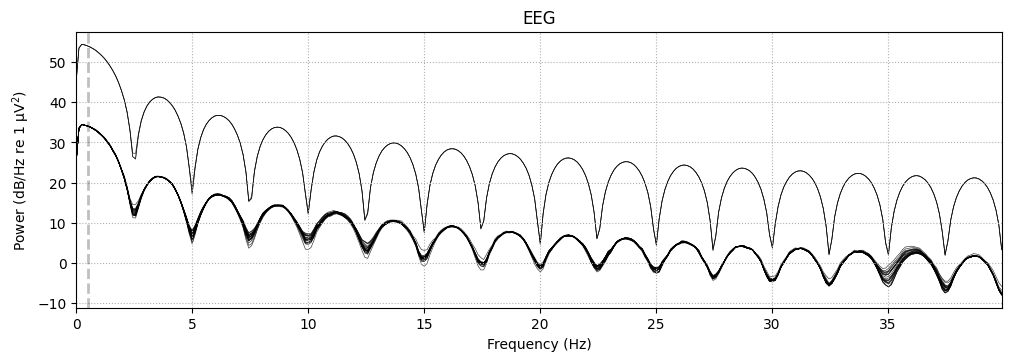

In [25]:
raw.compute_psd(fmax=40.0, picks="eeg", verbose="ERROR").plot(show=True)

## 6. Time–frequency EDA - mu-band (8–12 Hz) ERD/ERS at C3/Cz/C4
Sanity check: contralateral mu suppression should appear after cue onset for hand-imagery classes. Flat/absent ERD for a subject is a known indicator of a poor/low-performing BCI subject (e.g. subject 4 in this dataset is a documented weak performer).

Resolved sensorimotor channels: ['EEG-C3', 'EEG-Cz', 'EEG-C4']


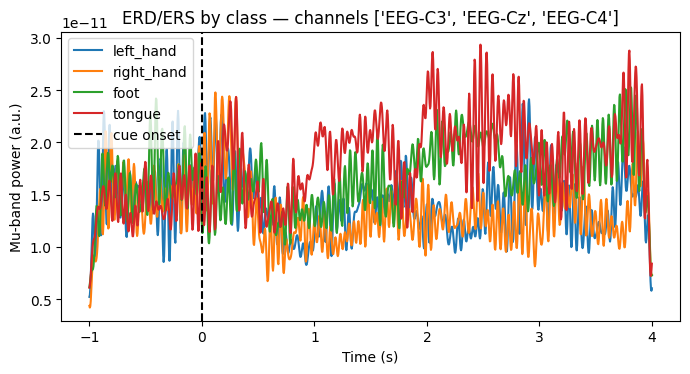

In [26]:
picks_raw = [find_channel(t, ch_names) for t in ("C3", "Cz", "C4")]
picks = [c for c in picks_raw if c is not None]
print(f"Resolved sensorimotor channels: {picks}")
if not picks:
    raise ValueError(
        f"Could not find C3/Cz/C4-equivalent channels among: {ch_names}. "
        f"Check the channel naming convention for this file and adjust find_channel targets."
    )

epochs = mne.Epochs(raw, cue_events, event_id=cue_ids, tmin=-1.0, tmax=4.0,
                     baseline=(-1.0, 0), preload=True, verbose="ERROR")
epochs_filt = epochs.copy().filter(8, 12, verbose="ERROR")

fig, ax = plt.subplots(figsize=(7, 4))
for label, code in cue_ids.items():
    ep = epochs_filt[label]
    power = (ep.get_data(picks=picks) ** 2).mean(axis=(0, 1))
    ax.plot(epochs_filt.times, power, label=CUE_CODES[label])

ax.axvline(0, linestyle="--", color="k", label="cue onset")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Mu-band power (a.u.)")
ax.set_title(f"ERD/ERS by class — channels {picks}")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Artifact / outlier screening
Peak-to-peak amplitude rejection (common threshold ~100–150 uV for EEG after typical BCI-IV preprocessing) to estimate the fraction of trials that would be dropped.

In [27]:
REJECT_THRESHOLD = 150e-6  # Volts, adjust as needed

eeg_epochs_data = epochs.get_data(picks="eeg")
ptp = eeg_epochs_data.max(axis=2) - eeg_epochs_data.min(axis=2)  # (n_trials, n_channels)
bad_trials = np.any(ptp > REJECT_THRESHOLD, axis=1)

print(f"Total trials: {len(bad_trials)}")
print(f"Trials exceeding {REJECT_THRESHOLD*1e6:.0f} uV peak-to-peak: {bad_trials.sum()} "
      f"({100*bad_trials.mean():.1f}%)")

Total trials: 288
Trials exceeding 150 uV peak-to-peak: 68 (23.6%)


## 8. Save summary to /kaggle/working/
Kaggle persists anything written to `/kaggle/working/` as notebook output.

In [28]:
import os

os.makedirs("/kaggle/working", exist_ok=True)
summary_path = "/kaggle/working/2a_eda_summary.txt"
with open(summary_path, "w") as f:
    f.write(f"File: {FILE_PATH}\n")
    f.write(f"Channels: {raw.ch_names}\n")
    f.write(f"Sampling rate: {raw.info['sfreq']} Hz\n")
    f.write(f"Class counts: {dict(zip(uniq, cnt))}\n")
    f.write(f"Bad trials (>{REJECT_THRESHOLD*1e6:.0f} uV): "
            f"{bad_trials.sum()} / {len(bad_trials)} ({100*bad_trials.mean():.1f}%)\n")

print(f"Saved to {summary_path}")

Saved to /kaggle/working/2a_eda_summary.txt
